# Phase 2 - Neural Network

## 1. Import Libraries

In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import Sequential, callbacks
from tensorflow.keras.layers import InputLayer, Dense, Dropout
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

## 2. Import Preprocessed Data

In [2]:
x_train = pd.read_csv("preprocessed/X_train_scaled.csv").to_numpy(dtype=np.float32)
x_test = pd.read_csv("preprocessed/X_test_scaled.csv").to_numpy(dtype=np.float32)
# Extracting the single label column as a 1D integer array.
y_train = pd.read_csv("preprocessed/y_train.csv").iloc[:, 0].to_numpy(dtype=np.int32)
y_test = pd.read_csv("preprocessed/y_test.csv").iloc[:, 0].to_numpy(dtype=np.int32)

print("Training", x_train.shape, y_train.shape)
print("Testing", x_test.shape, y_test.shape)

Training (1322089, 127) (1322089,)
Testing (566610, 127) (566610,)


## 3. ANN Training

### 3.1 Adjusting For Class Imbalance

In [5]:
# Using class weights to address class imbalance.
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))
print(class_weight)

{np.int32(0): np.float64(3.853206223004599), np.int32(1): np.float64(0.5745555099727778)}


### 3.2 Separating Validation Data for Hyperparameter Tuning

In [ ]:
x_tr, x_val, y_tr, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

### 3.3 Hyperparameter Tuning

This section uses a manual hyperparameter search with stratified holdout validation. The original training data is split into a smaller training subset and a validation subset while preserving the class distribution. Each neural network configuration is trained on the training subset and compared using validation AUC.

The hyperparameters tested include the hidden-layer structure, dropout rate, learning rate, and batch size. These settings control the model's capacity, regularization strength, optimization speed, and update frequency.

In [7]:
def build_model(layers, dropout, lr):
    model = Sequential()
    model.add(InputLayer(shape=(x_train.shape[1],)))

    for units in layers:
        model.add(Dense(units, activation="relu"))
        model.add(Dropout(dropout))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [9]:
configs = [
    {"layers": [128, 64], "dropout": 0.2, "lr": 1e-3, "batch": 256},
    {"layers": [256, 128, 64], "dropout": 0.3, "lr": 1e-3, "batch": 256},
    {"layers": [512, 256, 128], "dropout": 0.4, "lr": 5e-4, "batch": 256},
    {"layers": [256, 128], "dropout": 0.2, "lr": 1e-4, "batch": 128},
]

results = []

for config in configs:
    print("Testing:", config)

    model = build_model(
        layers=config["layers"],
        dropout=config["dropout"],
        lr=config["lr"]
    )

    es = callbacks.EarlyStopping(
        monitor="val_auc",
        patience=5,
        mode="max",
        restore_best_weights=True
    )

    history = model.fit(
        x_tr,
        y_tr,
        validation_data=(x_val, y_val),
        epochs=20,
        batch_size=config["batch"],
        class_weight=class_weight,
        callbacks=[es],
        verbose=1
    )

    best_val_auc = max(history.history["val_auc"])

    results.append({
        "layers": config["layers"],
        "dropout": config["dropout"],
        "learning_rate": config["lr"],
        "batch_size": config["batch"],
        "best_val_auc": best_val_auc
    })


Testing: {'layers': [128, 64], 'dropout': 0.2, 'lr': 0.001, 'batch': 256}
Epoch 1/20
4132/4132 ━━━━━━━━━━━━━━━━━━━━ 4s 816us/step - accuracy: 0.6224 - auc: 0.7288 - loss: 0.6054 - precision: 0.9375 - recall: 0.6065 - val_accuracy: 0.6103 - val_auc: 0.7441 - val_loss: 0.6227 - val_precision: 0.9444 - val_recall: 0.5868
Epoch 2/20
4132/4132 ━━━━━━━━━━━━━━━━━━━━ 3s 781us/step - accuracy: 0.6301 - auc: 0.7390 - loss: 0.5971 - precision: 0.9399 - recall: 0.6143 - val_accuracy: 0.6128 - val_auc: 0.7448 - val_loss: 0.6064 - val_precision: 0.9449 - val_recall: 0.5894
Epoch 3/20
4132/4132 ━━━━━━━━━━━━━━━━━━━━ 3s 752us/step - accuracy: 0.6329 - auc: 0.7414 - loss: 0.5952 - precision: 0.9402 - recall: 0.6174 - val_accuracy: 0.6468 - val_auc: 0.7473 - val_loss: 0.5866 - val_precision: 0.9390 - val_recall: 0.6354
Epoch 4/20
4132/4132 ━━━━━━━━━━━━━━━━━━━━ 3s 757us/step - accuracy: 0.6371 - auc: 0.7428 - loss: 0.5941 - precision: 0.9402 - recall: 0.6225 - val_accuracy: 0.6144 - val_auc: 0.7466 - val_

### 3.4 Selecting the Best Configuration and Training the Final Model

In [10]:
tuning_results = pd.DataFrame(results)
tuning_results.sort_values("best_val_auc", ascending=False)

,layers,dropout,learning_rate,batch_size,best_val_auc
3,"[256, 128]",0.2,0.0001,128,0.753088
0,"[128, 64]",0.2,0.0010,256,0.752188
2,"[512, 256, 128]",0.4,0.0005,256,0.751882
1,"[256, 128, 64]",0.3,0.0010,256,0.750794


### Why This Configuration Was Selected

After testing the candidate neural network configurations, the results were converted into a dataframe and sorted by `best_val_auc`. The configuration with the highest validation AUC was selected because AUC measures how well the model separates default and non-default outcomes across classification thresholds. This is more useful than accuracy for this dataset because the classes are imbalanced.

In [12]:
best_model = build_model(
    layers=[256, 128],
    dropout=0.2,
    lr=1e-4)

es = callbacks.EarlyStopping(
    monitor="val_auc",
    patience=5,
    mode="max",
    restore_best_weights=True
)

history = best_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[es],
    verbose=1
)


Epoch 1/20
4132/4132 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.5839 - auc: 0.6984 - loss: 0.6511 - precision: 0.9253 - recall: 0.5607 - val_accuracy: 0.7227 - val_auc: 0.8091 - val_loss: 0.5100 - val_precision: 0.9713 - val_recall: 0.7185
Epoch 2/20
4132/4132 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.5937 - auc: 0.7165 - loss: 0.6377 - precision: 0.9306 - recall: 0.5694 - val_accuracy: 0.7761 - val_auc: 0.8132 - val_loss: 0.4347 - val_precision: 0.9641 - val_recall: 0.7849
Epoch 3/20
4132/4132 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.5973 - auc: 0.7208 - loss: 0.6343 - precision: 0.9321 - recall: 0.5727 - val_accuracy: 0.7775 - val_auc: 0.8154 - val_loss: 0.4316 - val_precision: 0.9643 - val_recall: 0.7863
Epoch 4/20
4132/4132 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.5988 - auc: 0.7233 - loss: 0.6323 - precision: 0.9325 - recall: 0.5744 - val_accuracy: 0.7881 - val_auc: 0.8158 - val_loss: 0.4302 - val_precision: 0.9627 - val_recall: 0.7997
Epoch 5/20
4132/4132 ━━━

## 4. Model Evaluation

To evaluate the neural network, we used a diverse set of metrics rather than relying solely on accuracy. This is important because the Lending Club dataset is highly imbalanced: there are a lot more non-default loans than default loans. In such settings, a model can achieve deceptively high accuracy simply by predicting the majority class.

For this reason, we measured performance using:

- Accuracy  
- Precision  
- Recall  
- F1-score  
- AUC-ROC  
- Precision–Recall behavior

Together, these metrics offer a more complete understanding of how well the model predicts low-risk and high-risk loans.

---

### Why Accuracy Alone Is Not Enough

In imbalanced classification problems, accuracy can hide important behavior. A model may have high accuracy while performing badly on the minority class or lower accuracy while doing a better job detecting rare but important outcomes.


17707/17707 ━━━━━━━━━━━━━━━━━━━━ 3s 193us/step


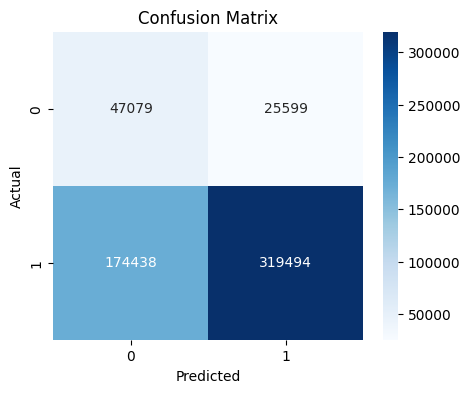


Classification Report:
              precision    recall  f1-score   support

           0       0.21      0.65      0.32     72678
           1       0.93      0.65      0.76    493932

    accuracy                           0.65    566610
   macro avg       0.57      0.65      0.54    566610
weighted avg       0.83      0.65      0.70    566610



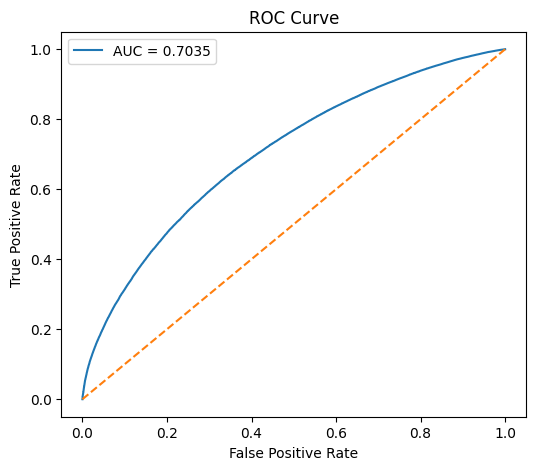

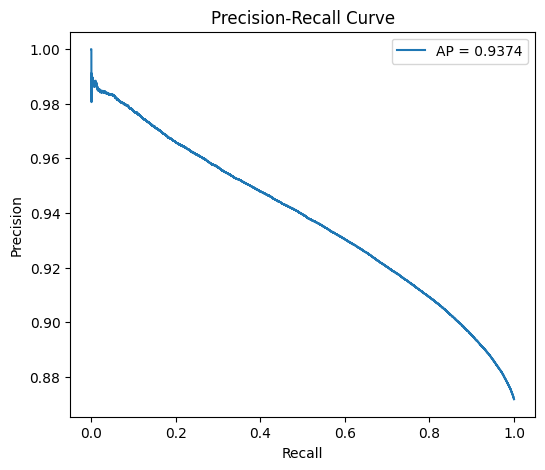

In [14]:
y_prob = best_model.predict(x_test).ravel()

# Starting with the standard 0.5 cutoff.
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
auc_roc = roc_auc_score(y_test, y_prob)
plt.plot(fpr, tpr, label=f"AUC = {auc_roc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Precision-Recall Curve
precisions, recalls, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
avg_precision = average_precision_score(y_test, y_prob)
plt.plot(recalls, precisions, label=f"AP = {avg_precision:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


### Training Outcome

Given the results above, the model shows evidence of learning meaningful predictive patterns from the preprocessed loan data in Phase 1. Earlier in development, this model behaved like a majority-class predictor, but scaling inputs, class weighting, and hyperparameter tuning improved its usefulness for the imbalanced lending task.

Validation AUC was used during tuning to select the best neural network configuration. For final reporting, the held-out test set is more important: the neural network achieved a test ROC-AUC of about **0.70** and an F1-score of about **0.76** at the default threshold of 0.5.

---

### Confusion Matrix Interpretation

At the default threshold of 0.5, the confusion matrix shows:

- The model correctly identifies a large number of non-default loans  
- It captures a meaningful portion of default-related cases  
- Some errors remain, especially false approvals and rejected good loans

Note: False positives and false negatives do not carry the same cost, making threshold selection a key part of the model strategy. Check the next section for our threshold and banking strategies' analysis.

---

### Classification Report

The classification report shows better performance on the majority class (non-default) than on the minority class (default). However, the model still captures useful signal for identifying risky loans, especially when the decision threshold is adjusted.

---

### AUC-ROC and Ranking Performance

The model achieved a test ROC-AUC of about **0.70**, indicating meaningful but not perfect separability. This confirms that the neural network is learning useful signal from the engineered features, while still showing why threshold tuning is needed for practical lending decisions.

## 5. Banking Strategies

### Threshold Analysis

To better understand tradeoffs between precision and recall, the model was evaluated using several thresholds: 0.3, 0.4, 0.5, 0.6, 0.7, 0.8

These results show a clear tradeoff:

- Lower thresholds -> higher recall, higher F1-score  
- Higher thresholds -> higher precision, lower recall  

These tradeoffs confirm that we need threshold tuning. The optimal threshold depends on the business goal:

- If the goal is to identify as many risky loans as possible, choose a lower threshold  
- If the goal is to reduce false approvals and stay conservative, choose a higher threshold  

For banking purposes, a higher threshold is recommended. This ensures that loans are approved only for clients the model is confident will not default, reducing exposure to risky borrowers.

In [15]:
# Comparing several cutoffs to see how different strategies change our outcome.
# Note: We are trading recall for precision as we increase the threshold, which means we will approve fewer loans but with higher confidence.
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

for t in thresholds_to_test:
    y_pred_t = (y_prob >= t).astype(int)

    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()

    print(f"Threshold: {t}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Approved (TP+FP): {tp+fp}")
    print(f"Bad approvals (FP): {fp}")
    print("---")

Threshold: 0.3
Precision: 0.8890
Recall:    0.9359
F1 Score:  0.9119
Approved (TP+FP): 520001
Bad approvals (FP): 57717
---
Threshold: 0.4
Precision: 0.9069
Recall:    0.8185
F1 Score:  0.8604
Approved (TP+FP): 445778
Bad approvals (FP): 41498
---
Threshold: 0.5
Precision: 0.9258
Recall:    0.6468
F1 Score:  0.7616
Approved (TP+FP): 345093
Bad approvals (FP): 25599
---
Threshold: 0.6
Precision: 0.9432
Recall:    0.4545
F1 Score:  0.6134
Approved (TP+FP): 237990
Bad approvals (FP): 13508
---
Threshold: 0.7
Precision: 0.9589
Recall:    0.2764
F1 Score:  0.4291
Approved (TP+FP): 142382
Bad approvals (FP): 5858
---
Threshold: 0.8
Precision: 0.9738
Recall:    0.1303
F1 Score:  0.2298
Approved (TP+FP): 66093
Bad approvals (FP): 1733
---


## 6. Saving Results (Phase 3)

In [16]:
# Default-threshold predictions
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

# Main evaluation metrics
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

summary_rows = [
    {"metric": "date", "value": datetime.now().strftime("%Y-%m-%d")},
    {"metric": "threshold", "value": threshold},
    {"metric": "accuracy", "value": accuracy_score(y_test, y_pred)},
    {"metric": "precision", "value": precision_score(y_test, y_pred)},
    {"metric": "recall", "value": recall_score(y_test, y_pred)},
    {"metric": "f1_score", "value": f1_score(y_test, y_pred)},
    {"metric": "roc_auc", "value": roc_auc_score(y_test, y_prob)},
    {"metric": "avg_precision", "value": average_precision_score(y_test, y_prob)},
    {"metric": "tn", "value": tn},
    {"metric": "fp", "value": fp},
    {"metric": "fn", "value": fn},
    {"metric": "tp", "value": tp},
]

summary_df = pd.DataFrame(summary_rows)

# Threshold sweep results
threshold_rows = []
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

for t in thresholds_to_test:
    y_pred_t = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    threshold_rows.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t),
        "recall": recall_score(y_test, y_pred_t),
        "f1_score": f1_score(y_test, y_pred_t),
        "approved_tp_fp": tp + fp,
        "bad_approvals_fp": fp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    })

threshold_df = pd.DataFrame(threshold_rows)

# File names
date_str = datetime.now().strftime("%Y-%m-%d")
summary_file = f"results/neural_network_{date_str}_summary.csv"
threshold_file = f"results/neural_network_{date_str}_thresholds.csv"

# Save
summary_df.to_csv(summary_file, index=False)
threshold_df.to_csv(threshold_file, index=False)

print(f"Saved summary to: {summary_file}")
print(f"Saved threshold results to: {threshold_file}")


Saved summary to: results/neural_network_2026-04-22_summary.csv
Saved threshold results to: results/neural_network_2026-04-22_thresholds.csv



## 7. Conclusion

The neural network can be considered successful for Phase 2. The results show that the model is learning meaningful patterns from the scaled loan features.

Key evidence of success includes:

- Test ROC-AUC around 0.70  
- F1-score around 0.76 at threshold 0.5  
- Meaningful detection of the minority/default class  
- Stronger F1-score at lower thresholds, especially threshold 0.3  

Additionally, testing multiple thresholds shows that model evaluation should not stop at the 0.5 threshold. Understanding precision, recall, F1, and bad approvals across different thresholds allows us to choose a better operating strategy for real-world credit-risk prediction.